# 🎯 Predictor — următoarea extragere (1–20)

Notebook-ul face patru lucruri:

1. **Încarcă și curăță** `history.csv` (duplicate, ordine, sloturi lipsă).
2. **Adaugă extragerile noi** fără să dubleze rânduri, chiar dacă rulezi celula de mai multe ori.
3. **Rulează mai multe modele în paralel**, le testează *walk-forward* pe istoric și le combină într-un **ansamblu** ponderat după cât de bine au mers.
4. Îți dă **până la 9 propuneri** pentru următoarea extragere, cu probabilitatea fiecăreia și cu **rata reală de nimerire din backtest**.

Secțiunea **9c · Detector de schimbare** te anunță dacă jocul începe să se comporte altfel, singura situație în care acuratețea ar putea crește.

> ⚠️ **Realist:** dacă generatorul e corect, nicio metodă nu bate șansa pe termen lung. Cu 9 propuneri, șansa pură e **9/20 = 45%**. Notebook-ul îți arată mereu, cinstit, dacă modelele fac mai bine decât atât sau nu.

**Cum îl folosești:** urcă `history.csv` lângă notebook în Deepnote, completează `NUMERE_NOI` din celula de configurare și apasă **Run all**.

## 1 · Configurare

In [1]:
DATA_PATH = "history.csv"          # fișierul cu istoricul (Date, Time, Drawn Number)
LOG_PATH = "predictions_log.csv"   # aici se salvează propunerile făcute, ca să le verifici ulterior

NUM_PROPUNERI = 9                  # câte numere vrei propuse (1–9)

# Extragerile noi, sub forma  "YYYY-MM-DD HH:MM": număr
# Poți rula de câte ori vrei: un slot care există deja NU se adaugă a doua oară.
# Celula 3 îți afișează exact cheia pentru următoarea extragere.
NUMERE_NOI = {
    # "2026-04-29 23:00": 5,
}

PRIMA_ORA, ULTIMA_ORA = 7, 23      # programul extragerilor (orar, 07:00–23:00)
TEST_SIZE = 6000                   # câte extrageri recente folosim pentru backtest
TIMP_INJUMATATIRE = 1000           # ponderile ansamblului: o extragere de acum 1000 ture contează pe jumătate

## 2 · Importuri și stil grafic

In [2]:
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, chisquare, chi2_contingency, ttest_1samp

K = 20                                     # numere posibile: 1..20
NUM_PROPUNERI = int(min(max(NUM_PROPUNERI, 1), 9))

BG, PANEL, GRID, TEXT = "#0f1117", "#1a1d27", "#2a2d3e", "#94a3b8"
C_MAIN, C_ACCENT, C_WARN, C_BAD = "#6c63ff", "#43d9ad", "#f6c90e", "#ff6b6b"

def style(fig, axes):
    fig.patch.set_facecolor(BG)
    for ax in np.atleast_1d(axes).ravel():
        ax.set_facecolor(PANEL)
        ax.tick_params(colors=TEXT)
        ax.title.set_color("white")
        ax.xaxis.label.set_color(TEXT)
        ax.yaxis.label.set_color(TEXT)
        for s in ax.spines.values():
            s.set_color(GRID)

## 3 · Încărcare, curățare și adăugare extrageri noi

In [3]:
def load_history(path):
    """Citește CSV-ul, elimină duplicatele exacte și sortează cronologic."""
    df = pd.read_csv(path, dtype={"Date": str, "Time": str})
    df["dt"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%Y-%m-%d %H:%M")
    df["n"] = df["Drawn Number"].astype(int)

    bad = df[(df["n"] < 1) | (df["n"] > K)]
    if len(bad):
        print(f"⚠️  Elimin {len(bad)} rânduri cu numere în afara 1–{K}")
        df = df.drop(bad.index)

    exact_dups = df.duplicated(subset=["dt", "n"]).sum()
    conflicts = df[df.duplicated(subset=["dt"], keep=False)].groupby("dt")["n"].nunique()
    conflicts = conflicts[conflicts > 1]
    if exact_dups:
        print(f"🧹 Elimin {exact_dups} rânduri duplicate (același slot, același număr)")
    if len(conflicts):
        print(f"⚠️  {len(conflicts)} sloturi au numere diferite; păstrez prima valoare:")
        for dt in conflicts.index[:5]:
            print("     ", dt)

    df = (df.drop_duplicates(subset=["dt"], keep="first")
            .sort_values("dt").reset_index(drop=True))
    return df[["Date", "Time", "Drawn Number", "dt", "n"]]


def next_slot(dt):
    """Slotul orar următor, în programul PRIMA_ORA–ULTIMA_ORA."""
    n = dt + pd.Timedelta(hours=1)
    if n.hour > ULTIMA_ORA:
        n = n.normalize() + pd.Timedelta(days=1, hours=PRIMA_ORA)
    elif n.hour < PRIMA_ORA:
        n = n.normalize() + pd.Timedelta(hours=PRIMA_ORA)
    return n


def expected_slots(start, end):
    days = pd.date_range(start.normalize(), end.normalize(), freq="D")
    slots = [d + pd.Timedelta(hours=h) for d in days for h in range(PRIMA_ORA, ULTIMA_ORA + 1)]
    return pd.DatetimeIndex([s for s in slots if start <= s <= end])


def add_draws(df, new_draws):
    """Adaugă extragerile noi. Idempotent: sloturile existente sunt sărite."""
    existing = dict(zip(df["dt"], df["n"]))
    rows = []
    for key, num in new_draws.items():
        dt = pd.Timestamp(key)
        num = int(num)
        if not 1 <= num <= K:
            print(f"❌ {key}: {num} nu e între 1 și {K} — sărit")
        elif dt in existing:
            if existing[dt] == num:
                print(f"↩️  {key} → {num} există deja — sărit")
            else:
                print(f"⚠️  {key} are deja {existing[dt]} în istoric (tu ai dat {num}) — nu suprascriu")
        elif not (PRIMA_ORA <= dt.hour <= ULTIMA_ORA and dt.minute == 0):
            print(f"❌ {key} nu e un slot valid ({PRIMA_ORA:02d}:00–{ULTIMA_ORA:02d}:00, la fix) — sărit")
        else:
            rows.append({"Date": dt.strftime("%Y-%m-%d"), "Time": dt.strftime("%H:%M"),
                         "Drawn Number": num, "dt": dt, "n": num})
            existing[dt] = num
            print(f"✅ Adăugat {key} → {num}")
    if rows:
        df = (pd.concat([df, pd.DataFrame(rows)], ignore_index=True)
                .sort_values("dt").reset_index(drop=True))
    return df, len(rows)


df = load_history(DATA_PATH)
df, added = add_draws(df, NUMERE_NOI)

raw_rows = sum(1 for _ in open(DATA_PATH)) - 1
if added or raw_rows != len(df):
    shutil.copy(DATA_PATH, DATA_PATH + ".bak")
    df[["Date", "Time", "Drawn Number"]].to_csv(DATA_PATH, index=False)
    print(f"💾 Salvat {DATA_PATH} ({len(df):,} rânduri). Copie de siguranță: {DATA_PATH}.bak")

missing = expected_slots(df["dt"].iloc[0], df["dt"].iloc[-1]).difference(pd.DatetimeIndex(df["dt"]))
last = df.iloc[-1]
NEXT_SLOT = next_slot(last["dt"])

print(f"\n📚 Istoric: {len(df):,} extrageri, {df['Date'].nunique():,} zile")
print(f"   Prima:   {df['dt'].iloc[0]:%Y-%m-%d %H:%M} → {df['n'].iloc[0]}")
print(f"   Ultima:  {last['dt']:%Y-%m-%d %H:%M} → {last['n']}")
if len(missing):
    print(f"   ⚠️  Sloturi lipsă în istoric: {len(missing)} (ex: {', '.join(f'{m:%Y-%m-%d %H:%M}' for m in missing[:3])})")
else:
    print("   Sloturi lipsă: 0 ✅")
print(f"\n👉 Următoarea extragere: \"{NEXT_SLOT:%Y-%m-%d %H:%M}\"   "
      f"(pune-o așa în NUMERE_NOI după ce o afli)")

🧹 Elimin 7 rânduri duplicate (același slot, același număr)
💾 Salvat history.csv (30,497 rânduri). Copie de siguranță: history.csv.bak



📚 Istoric: 30,497 extrageri, 1,794 zile
   Prima:   2021-06-01 07:00 → 5
   Ultima:  2026-04-29 22:00 → 19
   Sloturi lipsă: 0 ✅

👉 Următoarea extragere: "2026-04-29 23:00"   (pune-o așa în NUMERE_NOI după ce o afli)


## 4 · Cât de aleator e generatorul?

Aici se vede dacă există vreun tipar de exploatat. Un **p-value mic (< 0,01)** ar indica o abatere reală:

- **Uniformitate:** apar toate numerele la fel de des?
- **Serial:** depinde numărul de cel dinainte?
- **Oră din zi / zi a săptămânii:** apar unele numere mai des la anumite ore sau în anumite zile?

Test                                     p-value   Verdict
----------------------------------------------------------------
Uniformitate (frecvențe)                  0.2167   ✅ aleator
Serial (număr precedent → următor)        0.1121   ✅ aleator
Oră din zi                                0.9937   ✅ aleator
Zi a săptămânii                           0.7397   ✅ aleator


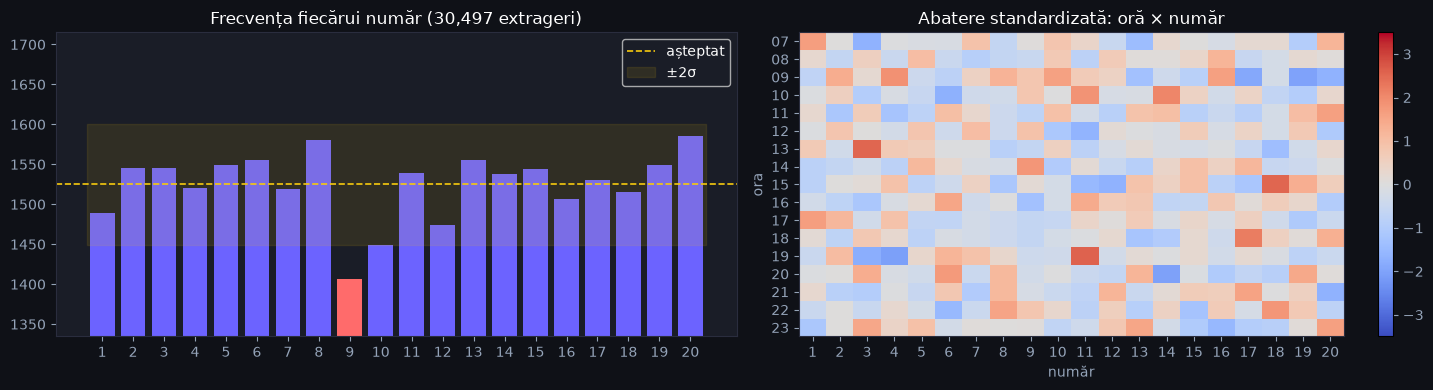

In [4]:
x = df["n"].to_numpy() - 1                   # intern lucrăm cu 0..19
hours = df["dt"].dt.hour.to_numpy()
dows = df["dt"].dt.dayofweek.to_numpy()
N = len(x)

def ct(a, b, na, nb):
    t = np.zeros((na, nb))
    np.add.at(t, (a, b), 1)
    return t[t.sum(1) > 0]

freq = np.bincount(x, minlength=K)
tests = {
    "Uniformitate (frecvențe)":        chisquare(freq).pvalue,
    "Serial (număr precedent → următor)": chi2_contingency(ct(x[:-1], x[1:], K, K))[1],
    "Oră din zi":                      chi2_contingency(ct(hours, x, 24, K))[1],
    "Zi a săptămânii":                 chi2_contingency(ct(dows, x, 7, K))[1],
}
print(f"{'Test':<38} {'p-value':>9}   Verdict")
print("-" * 64)
for name, p in tests.items():
    verdict = "⚠️  abatere" if p < 0.01 else ("🔶 la limită" if p < 0.05 else "✅ aleator")
    print(f"{name:<38} {p:>9.4f}   {verdict}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
style(fig, axes)
exp = N / K
sd = np.sqrt(N * (1 / K) * (1 - 1 / K))
cols = [C_BAD if f < exp - 2 * sd else C_ACCENT if f > exp + 2 * sd else C_MAIN for f in freq]
axes[0].bar(range(1, K + 1), freq, color=cols)
axes[0].axhline(exp, color=C_WARN, ls="--", lw=1.2, label="așteptat")
axes[0].fill_between([0.5, K + 0.5], exp - 2 * sd, exp + 2 * sd, color=C_WARN, alpha=0.1, label="±2σ")
axes[0].set_xticks(range(1, K + 1))
axes[0].set_ylim(exp - 5 * sd, exp + 5 * sd)
axes[0].set_title(f"Frecvența fiecărui număr ({N:,} extrageri)")
axes[0].legend(facecolor=PANEL, labelcolor="white")

tbl = ct(hours, x, 24, K)
exp_t = tbl.sum(1, keepdims=True) * tbl.sum(0, keepdims=True) / tbl.sum()
resid = (tbl - exp_t) / np.sqrt(exp_t)
im = axes[1].imshow(resid, aspect="auto", cmap="coolwarm", vmin=-3.5, vmax=3.5)
axes[1].set_xticks(range(K), range(1, K + 1))
axes[1].set_yticks(range(len(resid)), [f"{h:02d}" for h in sorted(set(hours))])
axes[1].set_title("Abatere standardizată: oră × număr")
axes[1].set_xlabel("număr")
axes[1].set_ylabel("ora")
cb = fig.colorbar(im, ax=axes[1])
cb.ax.tick_params(colors=TEXT)
plt.tight_layout()
plt.show()

## 5 · Modelele

Fiecare model dă o **distribuție de probabilitate pe cele 20 de numere**. La fiecare pas, fiecare model vede *doar trecutul*, deci nu există scurgere de informație din viitor.

| Model | Ideea |
|---|---|
| Uniform | referința: 5% pentru fiecare număr |
| Frecvență globală | numerele ieșite mai des în tot istoricul |
| Frecvență recentă | la fel, dar extragerile recente cântăresc mai mult (timp de înjumătățire 300) |
| Markov-1 | ce urmează de obicei după ultimul număr |
| Markov-2 | ce urmează de obicei după ultimele două numere |
| Oră din zi | ce iese de obicei la ora următoarei extrageri |
| Întârziere (gap) | cât de probabil e un număr după câte extrageri a lipsit |

Toate modelele folosesc **netezire bayesiană**: un context văzut de puține ori nu mai dă procente exagerate (ex. „13,7% din 51 apariții”), ci se apropie de media globală.

In [5]:
MODELS = ["Uniform", "Frecvență globală", "Frecvență recentă",
          "Markov-1", "Markov-2", "Oră din zi", "Întârziere (gap)"]

def walk_forward(x, hours, next_hour, alpha=1.0, b1=40.0, b2=40.0, bh=100.0,
                 half_life=300, gap_buckets=80, gap_prior=20.0):
    """P[m][t] = distribuția prezisă pentru extragerea t, folosind DOAR x[:t].
    Rândul t = len(x) este predicția pentru următoarea extragere (necunoscută)."""
    n = len(x)
    P = {m: np.empty((n + 1, K)) for m in MODELS}
    glob, rec = np.zeros(K), np.zeros(K)
    decay = 0.5 ** (1 / half_life)
    m1, m2, hr = np.zeros((K, K)), np.zeros((K, K, K)), np.zeros((24, K))
    last_seen = np.full(K, -1)
    gap_hits, gap_trials = np.zeros(gap_buckets), np.zeros(gap_buckets)
    uni = np.full(K, 1 / K)

    for t in range(n + 1):
        h = hours[t] if t < n else next_hour
        g = (glob + alpha) / (glob.sum() + K * alpha)
        p1 = (m1[x[t - 1]] + b1 * g) / (m1[x[t - 1]].sum() + b1) if t >= 1 else g
        p2 = (m2[x[t - 2], x[t - 1]] + b2 * p1) / (m2[x[t - 2], x[t - 1]].sum() + b2) if t >= 2 else p1
        bucket = np.minimum(t - last_seen, gap_buckets - 1)
        hazard = (gap_hits[bucket] + gap_prior / K) / (gap_trials[bucket] + gap_prior)

        P["Uniform"][t] = uni
        P["Frecvență globală"][t] = g
        P["Frecvență recentă"][t] = (rec + alpha) / (rec.sum() + K * alpha)
        P["Markov-1"][t] = p1
        P["Markov-2"][t] = p2
        P["Oră din zi"][t] = (hr[h] + bh * g) / (hr[h].sum() + bh)
        P["Întârziere (gap)"][t] = hazard / hazard.sum()

        if t == n:
            break
        v = x[t]
        glob[v] += 1
        rec *= decay
        rec[v] += 1
        if t >= 1:
            m1[x[t - 1], v] += 1
        if t >= 2:
            m2[x[t - 2], x[t - 1], v] += 1
        hr[h, v] += 1
        np.add.at(gap_trials, bucket, 1)
        gap_hits[bucket[v]] += 1
        last_seen[v] = t
    return P


def fit_weights(L, iters=300, half_life=None):
    """Ponderile optime ale ansamblului (EM pe mixtură).
    L[t, m] = probabilitatea dată de modelul m numărului care chiar a ieșit la t.
    half_life: extragerile recente contează mai mult (adaptare rapidă dacă jocul se schimbă)."""
    n = L.shape[0]
    sw = np.ones(n) if not half_life else 0.5 ** ((n - 1 - np.arange(n)) / half_life)
    sw /= sw.sum()
    w = np.full(L.shape[1], 1 / L.shape[1])
    for _ in range(iters):
        r = L * w
        r /= r.sum(1, keepdims=True)
        w = (r * sw[:, None]).sum(0)
    return w


def top_k(p, k):
    # sortare stabilă: la egalitate câștigă numărul mai mic
    return np.argsort(-p, kind="stable")[:k]


P = walk_forward(x, hours, NEXT_SLOT.hour)
print(f"✅ {len(MODELS)} modele calculate walk-forward pe {N:,} extrageri")

✅ 7 modele calculate walk-forward pe 30,497 extrageri


## 6 · Backtest: au bătut modelele șansa?

Ultimele `TEST_SIZE` extrageri se împart în două:

- **prima jumătate** calibrează ponderile ansamblului;
- **a doua jumătate** e test curat: ansamblul nu a văzut-o deloc.

Metrici:

- **Log-loss:** cât de bine estimează modelul probabilitățile. Mai mic e mai bine. Pentru uniform este ln 20 ≈ 2,9957.
- **Top-K:** cât de des numărul ieșit a fost printre cele K propuneri. Șansa pură e K × 5%.
- **p-value:** probabilitatea să obții un asemenea rezultat doar din noroc. Sub 0,01 e semnal real.

Test curat: 3,000 extrageri  (2025-11-04 → 2026-04-29)
Șansa pură pentru top-9: 45.0%



,Log-loss,Δ vs uniform,p (log-loss),Top-9 %,p (top-9)
Model,,,,,
Uniform,2.9957,+0.0000,nan,46.23,0.090
Frecvență globală,2.9962,-0.0005,0.812,43.90,0.891
Frecvență recentă,3.0063,-0.0106,1.000,45.03,0.492
Markov-1,3.0041,-0.0084,1.000,44.90,0.551
Markov-2,3.0544,-0.0587,1.000,45.63,0.248
Oră din zi,3.0016,-0.0059,1.000,44.00,0.869
Întârziere (gap),2.9961,-0.0004,0.683,45.60,0.260
⭐ Ansamblu,2.9963,-0.0005,0.873,45.07,0.478



Ponderi ansamblu (calibrate pe prima jumătate):
  Întârziere (gap)      25.0%  ██████████
  Uniform               24.6%  █████████
  Frecvență globală     21.0%  ████████
  Oră din zi            16.9%  ██████
  Frecvență recentă      6.1%  ██
  Markov-1               5.0%  ██
  Markov-2               1.2%  



Ansamblu — rata de nimerire pe test, cu interval de încredere 95%:
  K |  nimerit |          IC 95% | șansă pură
  1 |    4.70% |   3.97–5.52  % |       5.0%
  2 |    9.37% |   8.35–10.47 % |      10.0%
  3 |   14.03% |  12.81–15.33 % |      15.0%
  4 |   19.17% |  17.77–20.62 % |      20.0%
  5 |   24.37% |  22.84–25.94 % |      25.0%
  6 |   29.70% |  28.07–31.37 % |      30.0%
  7 |   34.60% |  32.90–36.33 % |      35.0%
  8 |   39.63% |  37.88–41.41 % |      40.0%
  9 |   45.07% |  43.28–46.87 % |      45.0%

ℹ️  Niciun model nu bate uniform semnificativ: pe datele astea, extragerile se comportă aleator.


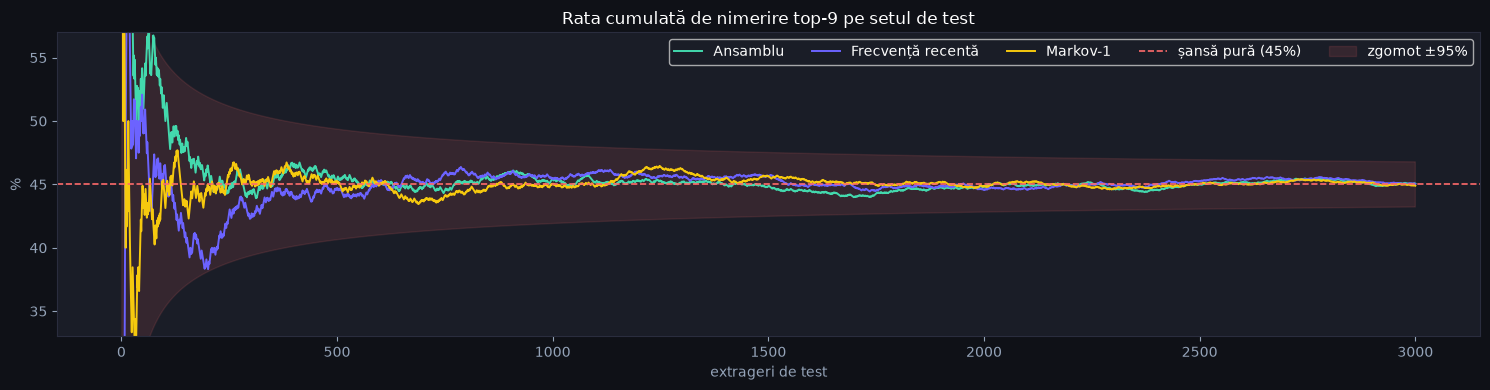

In [6]:
TEST_SIZE = min(TEST_SIZE, N - 1000)
half = TEST_SIZE // 2
cal = np.arange(N - TEST_SIZE, N - half)     # calibrare ponderi
tst = np.arange(N - half, N)                 # test curat

names = MODELS + ["⭐ Ansamblu"]
L_all = np.stack([P[m][np.arange(N), x] for m in MODELS], axis=1)
w_cal = fit_weights(L_all[cal], half_life=TIMP_INJUMATATIRE)
P_ens = sum(w * P[m] for w, m in zip(w_cal, MODELS))

def evaluate(Pm, idx, k):
    probs = Pm[idx]
    actual = x[idx]
    ll = -np.log(probs[np.arange(len(idx)), actual])
    hits_k = np.array([a in top_k(p, k) for p, a in zip(probs, actual)])
    bt = binomtest(hits_k.sum(), len(idx), k / K, alternative="greater")
    ll_p = ttest_1samp(np.log(K) - ll, 0, alternative="greater").pvalue
    return {"Log-loss": ll.mean(), "Δ vs uniform": np.log(K) - ll.mean(), "p (log-loss)": ll_p,
            f"Top-{k} %": 100 * hits_k.mean(), f"p (top-{k})": bt.pvalue, "hits": hits_k}

rows, HITS = [], {}
for name in names:
    r = evaluate(P_ens if name == "⭐ Ansamblu" else P[name], tst, NUM_PROPUNERI)
    HITS[name] = r.pop("hits")
    rows.append({"Model": name, **r})
report = pd.DataFrame(rows).set_index("Model")

print(f"Test curat: {len(tst):,} extrageri  ({df['dt'].iloc[tst[0]]:%Y-%m-%d} → {df['dt'].iloc[tst[-1]]:%Y-%m-%d})")
print(f"Șansa pură pentru top-{NUM_PROPUNERI}: {100 * NUM_PROPUNERI / K:.1f}%\n")
display(report.style.format({"Log-loss": "{:.4f}", "Δ vs uniform": "{:+.4f}", "p (log-loss)": "{:.3f}",
                             f"Top-{NUM_PROPUNERI} %": "{:.2f}", f"p (top-{NUM_PROPUNERI})": "{:.3f}"}))

print("\nPonderi ansamblu (calibrate pe prima jumătate):")
for m, w in sorted(zip(MODELS, w_cal), key=lambda z: -z[1]):
    print(f"  {m:<20} {100 * w:5.1f}%  {'█' * int(w * 40)}")

# Rata de nimerire a ansamblului pentru fiecare K = 1..9 (folosită la predicție)
ENS_HIT = {}
for k in range(1, 10):
    h = np.array([a in top_k(p, k) for p, a in zip(P_ens[tst], x[tst])])
    ci = binomtest(h.sum(), len(h), k / K).proportion_ci()
    ENS_HIT[k] = (100 * h.mean(), 100 * ci.low, 100 * ci.high)

print(f"\nAnsamblu — rata de nimerire pe test, cu interval de încredere 95%:")
print(f"{'K':>3} | {'nimerit':>8} | {'IC 95%':>15} | {'șansă pură':>10}")
for k, (m, lo, hi) in ENS_HIT.items():
    print(f"{k:>3} | {m:>7.2f}% | {lo:>6.2f}–{hi:<6.2f}% | {100 * k / K:>9.1f}%")

best = report.drop(index="Uniform")["p (log-loss)"].min()
print("\n" + ("⚡ Cel puțin un model bate uniform semnificativ (p < 0,01)." if best < 0.01 else
              "ℹ️  Niciun model nu bate uniform semnificativ: pe datele astea, extragerile se comportă aleator."))

fig, ax = plt.subplots(figsize=(15, 4))
style(fig, ax)
steps = np.arange(1, len(tst) + 1)
for name, color in [("⭐ Ansamblu", C_ACCENT), ("Frecvență recentă", C_MAIN), ("Markov-1", C_WARN)]:
    ax.plot(steps, 100 * np.cumsum(HITS[name]) / steps, color=color, lw=1.4, label=name.strip("⭐ "))
base = 100 * NUM_PROPUNERI / K
band = 196 * np.sqrt((NUM_PROPUNERI / K) * (1 - NUM_PROPUNERI / K) / steps)
ax.axhline(base, color=C_BAD, ls="--", lw=1.2, label=f"șansă pură ({base:.0f}%)")
ax.fill_between(steps, base - band, base + band, color=C_BAD, alpha=0.12, label="zgomot ±95%")
ax.set_ylim(base - 12, base + 12)
ax.set_title(f"Rata cumulată de nimerire top-{NUM_PROPUNERI} pe setul de test")
ax.set_xlabel("extrageri de test")
ax.set_ylabel("%")
ax.legend(facecolor=PANEL, labelcolor="white", ncol=5, loc="upper right")
plt.tight_layout()
plt.show()

## 7 · 🎯 Propunerile pentru următoarea extragere

Ponderile ansamblului se recalibrează pe **toată** fereastra de backtest, cu accent pe perioada recentă (`TIMP_INJUMATATIRE`). Dacă un model începe să funcționeze, ansamblul îi dă repede mai multă greutate. Apoi ansamblul combină predicțiile modelelor pentru slotul următor.

  PROPUNERI pentru 2026-04-29 23:00   (ultimul: 19)
  1. 13    5.37%   (+0.37 față de 5%)   ██████████████
  2.  3    5.34%   (+0.34 față de 5%)   █████████████
  3. 12    5.33%   (+0.33 față de 5%)   █████████████
  4.  5    5.19%   (+0.19 față de 5%)   ███████
  5.  8    5.14%   (+0.14 față de 5%)   █████
  6. 10    5.13%   (+0.13 față de 5%)   █████
  7. 20    5.12%   (+0.12 față de 5%)   ████
  8.  2    5.07%   (+0.07 față de 5%)   ██
  9.  7    5.01%   (+0.01 față de 5%)   
--------------------------------------------------------
  Șansa estimată ca numărul să fie în listă:  46.7%
  Rata reală în backtest (top-9):          45.1%  (IC 95%: 43.3–46.9%)
  Șansa pură:                                 45.0%

  🎯 [13]  [3]  [12]  [5]  [8]  [10]  [20]  [2]  [7]


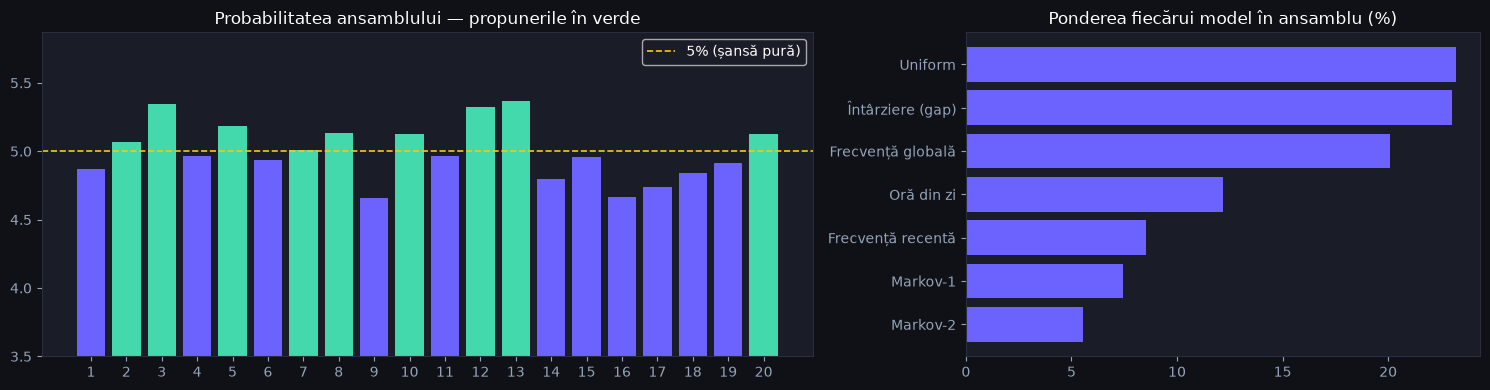

Ce ar propune fiecare model separat:


,#1,#2,#3,#4,#5,#6,#7,#8,#9
Frecvență globală,20,8,6,13,5,19,2,3,15
Frecvență recentă,2,10,5,6,12,8,13,18,15
Markov-1,19,5,3,8,12,10,20,11,15
Markov-2,13,3,12,10,7,5,4,8,20
Oră din zi,20,13,3,5,12,8,4,19,2
Întârziere (gap),12,1,2,6,8,15,17,20,11


In [7]:
def show_prediction():
    """Calibrează ansamblul pe ultimele TEST_SIZE extrageri și afișează propunerile pentru NEXT_SLOT."""
    global PROPUNERI
    w_final = fit_weights(L_all[N - TEST_SIZE:], half_life=TIMP_INJUMATATIRE)
    p_next = sum(w * P[m][N] for w, m in zip(w_final, MODELS))
    picks = top_k(p_next, NUM_PROPUNERI)
    PROPUNERI = [int(i) + 1 for i in picks]

    hit, lo, hi = ENS_HIT[NUM_PROPUNERI]
    print("=" * 56)
    print(f"  PROPUNERI pentru {NEXT_SLOT:%Y-%m-%d %H:%M}   (ultimul: {df['n'].iloc[-1]})")
    print("=" * 56)
    for r, i in enumerate(picks, 1):
        edge = 100 * (p_next[i] - 1 / K)
        print(f"  {r}. {i + 1:>2}   {100 * p_next[i]:5.2f}%   ({edge:+.2f} față de 5%)   {'█' * max(0, int(edge * 40))}")
    print("-" * 56)
    print(f"  Șansa estimată ca numărul să fie în listă:  {100 * p_next[picks].sum():.1f}%")
    print(f"  Rata reală în backtest (top-{NUM_PROPUNERI}):          {hit:.1f}%  (IC 95%: {lo:.1f}–{hi:.1f}%)")
    print(f"  Șansa pură:                                 {100 * NUM_PROPUNERI / K:.1f}%")
    print("=" * 56)
    print("\n  🎯 " + "  ".join(f"[{n}]" for n in PROPUNERI))

    fig, axes = plt.subplots(1, 2, figsize=(15, 4), gridspec_kw={"width_ratios": [3, 2]})
    style(fig, axes)
    cols = [C_ACCENT if i in picks else C_MAIN for i in range(K)]
    axes[0].bar(range(1, K + 1), 100 * p_next, color=cols)
    axes[0].axhline(100 / K, color=C_WARN, ls="--", lw=1.2, label="5% (șansă pură)")
    axes[0].set_xticks(range(1, K + 1))
    axes[0].set_ylim(100 / K - 1.5, max(100 * p_next.max(), 100 / K) + 0.5)
    axes[0].set_title(f"Probabilitatea ansamblului — propunerile în verde")
    axes[0].legend(facecolor=PANEL, labelcolor="white")

    order = np.argsort(w_final)
    axes[1].barh([MODELS[i] for i in order], 100 * w_final[order], color=C_MAIN)
    axes[1].set_title("Ponderea fiecărui model în ansamblu (%)")
    plt.tight_layout()
    plt.show()

    per_model = pd.DataFrame({m: [int(i) + 1 for i in top_k(P[m][N], NUM_PROPUNERI)] for m in MODELS[1:]},
                             index=[f"#{r}" for r in range(1, NUM_PROPUNERI + 1)]).T
    print("Ce ar propune fiecare model separat:")
    display(per_model)


show_prediction()

## 8 · Jurnalul propunerilor

Fiecare rulare salvează propunerile în `predictions_log.csv`, câte o singură intrare pe slot. După ce introduci rezultatul real (celula 10 sau `NUMERE_NOI`), aici vezi **cât ai nimerit în realitate**.

In [8]:
def update_log():
    """Salvează propunerile pentru NEXT_SLOT (o dată pe slot) și arată rezultatele reale."""
    log_cols = ["slot", "propuneri", "k", "creat_la"]
    log = pd.read_csv(LOG_PATH, dtype=str) if Path(LOG_PATH).exists() else pd.DataFrame(columns=log_cols)
    slot_key = f"{NEXT_SLOT:%Y-%m-%d %H:%M}"
    if slot_key not in set(log["slot"]):
        log.loc[len(log)] = [slot_key, " ".join(map(str, PROPUNERI)), str(NUM_PROPUNERI),
                             pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")]
        log.to_csv(LOG_PATH, index=False)
        print(f"📝 Am salvat propunerile pentru {slot_key}")
    else:
        print(f"ℹ️  Există deja propuneri pentru {slot_key} în jurnal (nu le suprascriu)")

    actual = dict(zip(df["dt"].dt.strftime("%Y-%m-%d %H:%M"), df["n"]))
    log["rezultat"] = log["slot"].map(actual).astype("Int64")
    done = log.dropna(subset=["rezultat"]).copy()
    if len(done):
        done["nimerit"] = [int(r) in map(int, p.split()) for r, p in zip(done["rezultat"], done["propuneri"])]
        exp_rate = (done["k"].astype(int) / K).mean()
        print(f"\n📊 Rezultate reale: {done['nimerit'].sum()} / {len(done)} nimerite "
              f"({100 * done['nimerit'].mean():.1f}%, șansa pură ≈ {100 * exp_rate:.1f}%)")
        display(done.tail(20)[["slot", "propuneri", "rezultat", "nimerit"]])
    else:
        print("\nÎncă nu există rezultate pentru propunerile din jurnal: introdu numărul extras în celula de mai jos.")


update_log()

📝 Am salvat propunerile pentru 2026-04-29 23:00

Încă nu există rezultate pentru propunerile din jurnal: introdu numărul extras în celula de mai jos.


## 9 · 🔁 Câte ture sunt între nimeriri?

O secvență ca *nimerit, ratat, ratat, nimerit* înseamnă **2 ture ratate** între nimeriri. Secțiunea arată:

1. **Cât de des apare fiecare pauză** (0, 1, 2, … ture ratate), pe backtest-ul de 3.000 de extrageri, comparată cu teoria.
2. **Dacă după mai multe ratări crește șansa de nimerire.** Spoiler: nu crește, fiecare tură e independentă.
3. **Situația ta reală** din jurnal: pauzele tale, seria curentă de ratări și șansa de a nimeri **măcar o dată în următoarele n ture**.

Backtest top-9: 3,000 ture, nimerit 45.1%
Ture ratate între nimeriri: medie 1.22 (teoretic 1.22), cea mai lungă pauză: 13 ture



Pauză (ture ratate),Observat %,Teoretic %,Șansa de nimerire DUPĂ atâtea ratări %,Cazuri
0,44.3,45.1,44.3,1353
1,25.6,24.8,45.9,753
2,14.4,13.6,48.0,406
3,7.0,7.5,45.0,211
4,4.0,4.1,46.6,116
5,1.6,2.3,35.5,62
6,1.3,1.2,45.0,40
7,0.4,0.7,22.7,22
8,0.8,0.4,64.7,17
9,0.0,0.2,0.0,6


👉 Ultima coloană rămâne în jur de 45% oricâte ratări ar fi fost înainte: o serie de ratări NU face nimerirea mai probabilă.


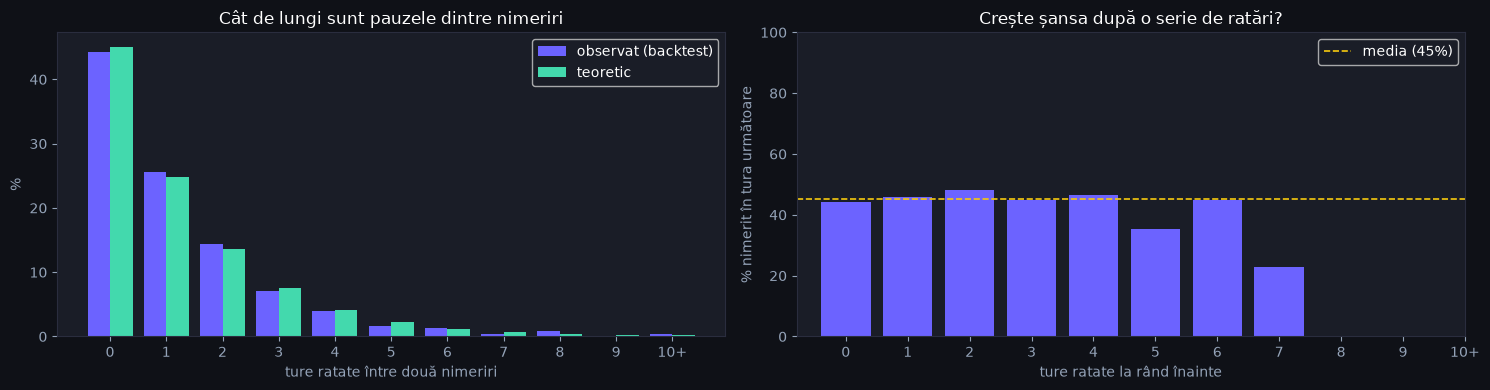


Cu 9 propuneri, șansa de a nimeri MĂCAR O DATĂ în următoarele n ture (indiferent câte ai ratat până acum):
    1 tură:  45.1%
    2 ture:  69.8%
    3 ture:  83.4%
    4 ture:  90.9%
    5 ture:  95.0%
    6 ture:  97.3%
    8 ture:  99.2%
   10 ture:  99.7%


In [9]:
def miss_gaps(hits):
    """Ture ratate între două nimeriri consecutive."""
    idx = np.flatnonzero(hits)
    return np.diff(idx) - 1

def current_streak(hits):
    """Câte ture ratate la rând sunt chiar acum, la finalul seriei."""
    hits = np.asarray(hits, bool)
    return len(hits) if not hits.any() else len(hits) - 1 - np.flatnonzero(hits)[-1]

bt_hits = HITS["⭐ Ansamblu"]                 # nimeriri top-K ale ansamblului pe testul curat
p = bt_hits.mean()
gaps = miss_gaps(bt_hits)
MAXG = 10

obs = np.bincount(np.minimum(gaps, MAXG), minlength=MAXG + 1) / len(gaps)
theo = np.array([p * (1 - p) ** k for k in range(MAXG)] + [(1 - p) ** MAXG])

print(f"Backtest top-{NUM_PROPUNERI}: {len(bt_hits):,} ture, nimerit {100 * p:.1f}%")
print(f"Ture ratate între nimeriri: medie {gaps.mean():.2f} (teoretic {(1 - p) / p:.2f}), "
      f"cea mai lungă pauză: {gaps.max()} ture\n")

# P(nimerit | după k ratări la rând)
run, cnt, hit_after = 0, np.zeros(MAXG + 1), np.zeros(MAXG + 1)
for h in bt_hits:
    r = min(run, MAXG)
    cnt[r] += 1
    hit_after[r] += h
    run = 0 if h else run + 1

tbl = pd.DataFrame({
    "Pauză (ture ratate)": [str(k) for k in range(MAXG)] + [f"{MAXG}+"],
    "Observat %": 100 * obs,
    "Teoretic %": 100 * theo,
    "Șansa de nimerire DUPĂ atâtea ratări %": 100 * hit_after / np.maximum(cnt, 1),
    "Cazuri": cnt.astype(int),
})
display(tbl.style.format({"Observat %": "{:.1f}", "Teoretic %": "{:.1f}",
                          "Șansa de nimerire DUPĂ atâtea ratări %": "{:.1f}"}).hide(axis="index"))
print(f"👉 Ultima coloană rămâne în jur de {100 * p:.0f}% oricâte ratări ar fi fost înainte: "
      f"o serie de ratări NU face nimerirea mai probabilă.")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
style(fig, axes)
lbl = [str(k) for k in range(MAXG)] + [f"{MAXG}+"]
axes[0].bar(np.arange(MAXG + 1) - 0.2, 100 * obs, width=0.4, color=C_MAIN, label="observat (backtest)")
axes[0].bar(np.arange(MAXG + 1) + 0.2, 100 * theo, width=0.4, color=C_ACCENT, label="teoretic")
axes[0].set_xticks(range(MAXG + 1), lbl)
axes[0].set_xlabel("ture ratate între două nimeriri")
axes[0].set_ylabel("%")
axes[0].set_title("Cât de lungi sunt pauzele dintre nimeriri")
axes[0].legend(facecolor=PANEL, labelcolor="white")
ok = cnt >= 20
axes[1].bar(np.arange(MAXG + 1)[ok], (100 * hit_after / np.maximum(cnt, 1))[ok], color=C_MAIN)
axes[1].axhline(100 * p, color=C_WARN, ls="--", lw=1.2, label=f"media ({100 * p:.0f}%)")
axes[1].set_xticks(range(MAXG + 1), lbl)
axes[1].set_ylim(0, 100)
axes[1].set_xlabel("ture ratate la rând înainte")
axes[1].set_ylabel("% nimerit în tura următoare")
axes[1].set_title("Crește șansa după o serie de ratări?")
axes[1].legend(facecolor=PANEL, labelcolor="white")
plt.tight_layout()
plt.show()

# ── Situația ta reală, din jurnal ─────────────────────────────
if Path(LOG_PATH).exists():
    lg = pd.read_csv(LOG_PATH, dtype=str)
    real = dict(zip(df["dt"].dt.strftime("%Y-%m-%d %H:%M"), df["n"]))
    lg["rezultat"] = lg["slot"].map(real)
    lg = lg.dropna(subset=["rezultat"]).sort_values("slot")
else:
    lg = pd.DataFrame()

if len(lg):
    live = np.array([int(r) in map(int, s.split()) for r, s in zip(lg["rezultat"], lg["propuneri"])])
    lg_gaps = miss_gaps(live)
    streak = current_streak(live)
    print(f"\n📒 Jurnalul tău: {live.sum()} nimeriri din {len(live)} ture")
    print("   Secvența (✓ nimerit, · ratat): " + "".join("✓" if h else "·" for h in live[-60:]))
    if len(lg_gaps):
        print(f"   Pauzele tale între nimeriri: {', '.join(map(str, lg_gaps[-25:]))}")
        print(f"   Medie: {lg_gaps.mean():.2f} ture (teoretic {(1 - p) / p:.2f}); cea mai lungă: {lg_gaps.max()}")
    print(f"   Acum ești la {streak} {'tură ratată' if streak == 1 else 'ture ratate'} la rând.")
print(f"\nCu {NUM_PROPUNERI} propuneri, șansa de a nimeri MĂCAR O DATĂ în următoarele n ture "
      f"(indiferent câte ai ratat până acum):")
for n_ in [1, 2, 3, 4, 5, 6, 8, 10]:
    print(f"   {n_:>2} {'tură' if n_ == 1 else 'ture'}: {100 * (1 - (1 - p) ** n_):5.1f}%")


def streak_alert():
    """Alertă informativă: la câte ratări la rând ești și cât de rară e o asemenea serie."""
    if not Path(LOG_PATH).exists():
        return
    lg = pd.read_csv(LOG_PATH, dtype=str)
    real = dict(zip(df["dt"].dt.strftime("%Y-%m-%d %H:%M"), df["n"]))
    lg["rezultat"] = lg["slot"].map(real)
    lg = lg.dropna(subset=["rezultat"]).sort_values("slot")
    if not len(lg):
        return
    live = np.array([int(r) in map(int, s.split()) for r, s in zip(lg["rezultat"], lg["propuneri"])])
    s = current_streak(live)
    q = 1 - NUM_PROPUNERI / K                       # șansa de ratare într-o tură
    print("\n" + "─" * 56)
    if s == 0:
        print("🔔 ALERTĂ SERIE: ultima tură a fost NIMERITĂ ✅")
    else:
        every = 1 / ((1 - q) * q ** s)              # o serie de ≥ s ratări începe cam o dată la atâtea ture
        days = every / (ULTIMA_ORA - PRIMA_ORA + 1)
        level = "🟢 normal" if q ** s > 0.10 else ("🟡 mai rar" if q ** s > 0.02 else "🔴 foarte rar")
        cand = f"~{every:.0f} ture" + (f" (~{days:.1f} zile)" if days >= 1 else "")
        print(f"🔔 ALERTĂ SERIE: {s} {'tură ratată' if s == 1 else 'ture ratate'} la rând  →  {level}")
        what = "o ratare" if s == 1 else f"{s} sau mai multe ratări la rând"
        print(f"   {what[0].upper() + what[1:]} {'apare' if s == 1 else 'apar'} cam o dată la {cand} (cu {NUM_PROPUNERI} propuneri).")
    print(f"   Șansa ca următoarea tură să fie nimerită: {100 * (1 - q):.0f}% — la fel ca întotdeauna;")
    print("   seria de până acum NU schimbă șansa următoarei ture.")
    print("─" * 56)


streak_alert()

### 9b · Tiparul „multe ratări → o nimerire → multe ratări”

Verifică dacă după o pauză lungă, o singură nimerire și apoi **încă o pauză lungă** apar mai des (sau mai rar) decât la întâmplare. Mai precis, compară:

- **pe tot istoricul**, cu propunerile pe care le-ar fi făcut ansamblul (top-`NUM_PROPUNERI`);
- **în jurnalul tău real**, pe măsură ce se adună date.

*Observat / așteptat* aproape de 1 înseamnă că tiparul apare cât la întâmplare. Un tipar real ar avea un p mic (< 0,01) pe tot istoricul, iar jurnalul tău ar trebui să-l confirme în timp.

Pragul pentru „pauză lungă” se schimbă din `PRAG_PAUZA` (implicit 4 ratări la rând).

In [10]:
from scipy.stats import pearsonr, poisson

PRAG_PAUZA = 4          # de la câte ratări la rând considerăm o pauză „lungă”

def pattern_stats(hits, L, q):
    """Numără tiparul ≥L ratări → 1 nimerire → ≥L ratări și îl compară cu întâmplarea."""
    gaps = miss_gaps(hits)
    if len(gaps) < 2:
        return None
    obs = int(((gaps[:-1] >= L) & (gaps[1:] >= L)).sum())
    exp = (len(gaps) - 1) * q ** (2 * L)
    first_long = gaps[:-1] >= L
    after = (gaps[1:][first_long] >= L).mean() if first_long.any() else np.nan
    # p cu două direcții (tiparul e mai des SAU mai rar decât la întâmplare)
    p_val = min(1.0, 2 * min(poisson.cdf(obs, exp), poisson.sf(obs - 1, exp))) if exp > 0 else np.nan
    return obs, exp, after, int(first_long.sum()), p_val

q = 1 - NUM_PROPUNERI / K

# ── Pe tot istoricul (propunerile ansamblului, fără să vadă viitorul) ──
full_idx = np.arange(2000, N)
order = np.argsort(-P_ens[full_idx], axis=1, kind="stable")
rank_pos = np.argmax(order == x[full_idx][:, None], axis=1)
hist_hits = rank_pos < NUM_PROPUNERI
q_hist = 1 - hist_hits.mean()
g_hist = miss_gaps(hist_hits)
r, p_r = pearsonr(g_hist[:-1], g_hist[1:])

rows = []
for L in sorted({3, 4, 5, 6, 8, PRAG_PAUZA}):
    obs, exp, after, n_long, p_val = pattern_stats(hist_hits, L, q_hist)
    rows.append({"Pauză lungă = ≥ ratări": L, "Observat": obs, "Așteptat la întâmplare": exp,
                 "Observat / așteptat": obs / exp if exp else np.nan,
                 "După o pauză lungă, următoarea e tot lungă %": 100 * after,
                 "Teoretic %": 100 * q_hist ** L, "p": p_val})
hist_tbl = pd.DataFrame(rows)

print(f"Tot istoricul: {len(hist_hits):,} ture cu top-{NUM_PROPUNERI} (nimerit {100 * hist_hits.mean():.1f}%)\n")
display(hist_tbl.style.format({"Așteptat la întâmplare": "{:.1f}", "Observat / așteptat": "{:.2f}",
                               "După o pauză lungă, următoarea e tot lungă %": "{:.1f}",
                               "Teoretic %": "{:.1f}", "p": "{:.3f}"}).hide(axis="index"))
print(f"Legătura dintre lungimile a două pauze consecutive: corelație {r:+.3f} (p = {p_r:.3f})")
min_p = np.nanmin(hist_tbl["p"].to_numpy())
if min_p * len(hist_tbl) < 0.01:
    print("⚡ Pe istoric, tiparul apare diferit de întâmplare: urmărește dacă jurnalul tău îl confirmă.")
else:
    print("ℹ️  Pe istoric, tiparul apare cât la întâmplare (după corecția pentru mai multe praguri testate).")

# ── În jurnalul tău real ───────────────────────────────────────
if Path(LOG_PATH).exists():
    lg = pd.read_csv(LOG_PATH, dtype=str)
    real = dict(zip(df["dt"].dt.strftime("%Y-%m-%d %H:%M"), df["n"]))
    lg["rezultat"] = lg["slot"].map(real)
    lg = lg.dropna(subset=["rezultat"]).sort_values("slot").reset_index(drop=True)
else:
    lg = pd.DataFrame()

print(f"\n📒 Jurnalul tău (pauză lungă = ≥{PRAG_PAUZA} ratări la rând):")
if len(lg) < 2:
    print("   Încă nu sunt destule rezultate în jurnal.")
else:
    live = np.array([int(v) in map(int, s.split()) for v, s in zip(lg["rezultat"], lg["propuneri"])])
    res = pattern_stats(live, PRAG_PAUZA, q)
    hit_idx = np.flatnonzero(live)
    g_live = miss_gaps(live)
    examples = [(g_live[i], lg["slot"].iloc[hit_idx[i + 1]], g_live[i + 1])
                for i in range(len(g_live) - 1) if g_live[i] >= PRAG_PAUZA and g_live[i + 1] >= PRAG_PAUZA]
    if res is None:
        print(f"   {len(live)} ture, {live.sum()} nimeriri: prea puține nimeriri pentru a vedea pauze consecutive.")
    else:
        obs, exp, after, n_long, _ = res
        print(f"   {len(live)} ture, {live.sum()} nimeriri, {len(g_live)} pauze între nimeriri.")
        print(f"   Tiparul a apărut de {obs} ori (la întâmplare ~{exp:.1f}).")
        if n_long:
            print(f"   După cele {n_long} pauze lungi, următoarea a fost tot lungă în {100 * after:.0f}% din cazuri "
                  f"(la întâmplare {100 * q ** PRAG_PAUZA:.0f}%).")
        for a, slot, b in examples[-5:]:
            print(f"   • {a} ratări → nimerit la {slot} → {b} ratări")
        if len(g_live) < 50:
            print(f"   ⏳ Doar {len(g_live)} pauze: ai nevoie de câteva sute ca să tragi o concluzie.")

Tot istoricul: 28,497 ture cu top-9 (nimerit 44.6%)



Pauză lungă = ≥ ratări,Observat,Așteptat la întâmplare,Observat / așteptat,"După o pauză lungă, următoarea e tot lungă %",Teoretic %,p
3,378,368.8,1.02,17.4,17.0,0.645
4,84,113.4,0.74,7.1,9.4,0.005
5,18,34.9,0.52,2.7,5.2,0.003
6,9,10.7,0.84,2.3,2.9,0.745
8,2,1.0,1.98,1.7,0.9,0.538


Legătura dintre lungimile a două pauze consecutive: corelație -0.017 (p = 0.056)
ℹ️  Pe istoric, tiparul apare cât la întâmplare (după corecția pentru mai multe praguri testate).



📒 Jurnalul tău (pauză lungă = ≥4 ratări la rând):
   Încă nu sunt destule rezultate în jurnal.


## 9c · 🚨 Detector de schimbare

Pe istoricul de până acum, extragerile se comportă aleator, deci nicio metodă nu bate șansa. **Singura situație în care acuratețea ar putea crește este dacă generatorul se schimbă**, de exemplu după o actualizare de software sau o altă setare. Secțiunea verifică perioada **recentă** (ultimele 500 și 1.700 de extrageri, adică ~1 lună și ~3 luni):

- apar toate numerele la fel de des?
- se repetă numărul anterior mai des decât 5%?
- sunt diferențele dintre extragerile consecutive uniforme?
- apar unele numere mai des la anumite ore?
- **bate vreun model șansa în perioada recentă?**

Fiecare p-value e corectat pentru numărul de verificări, deci alarma nu sună din întâmplare.

**🚨 = merită investigat** (rulează din nou Laboratorul, cercetarea sau cere-mi o analiză nouă). **✅ = nimic nou.**

Perioada verificată: ultimele 500 extrageri (din 2026-03-31) și ultimele 1.700 (din 2026-01-19); 11 verificări



Fereastră,Verificare,p,p corectat,Stare
500,uniformitate (frecvențe),0.9169,1.000,✅ normal
500,repetă numărul anterior,1.0000,1.000,✅ normal
500,diferențe între extrageri consecutive,0.9882,1.000,✅ normal
500,cel mai bun model bate șansa? (Întârziere (gap)),1.0000,1.000,✅ normal
500,ansamblul top-9 bate șansa? (45.4%),0.4458,1.000,✅ normal
1700,uniformitate (frecvențe),0.6573,1.000,✅ normal
1700,repetă numărul anterior,0.8237,1.000,✅ normal
1700,diferențe între extrageri consecutive,0.9936,1.000,✅ normal
1700,oră din zi × număr,0.0438,0.482,✅ normal
1700,cel mai bun model bate șansa? (Frecvență globală),1.0000,1.000,✅ normal



✅ Nicio schimbare: generatorul se comportă la fel ca până acum.


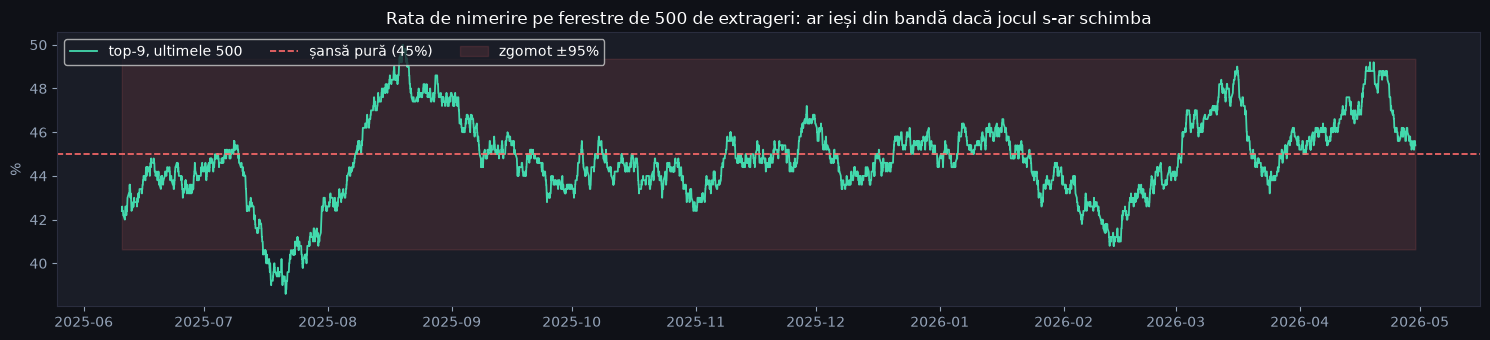

In [11]:
def drift_check():
    checks = []          # (fereastră, verificare, p)
    for W in (500, 1700):
        W = min(W, N - 1)
        xs = x[-W:]
        checks.append((W, "uniformitate (frecvențe)", chisquare(np.bincount(xs, minlength=K)).pvalue))
        rep = int((x[-W:] == x[-W - 1:-1]).sum())
        checks.append((W, "repetă numărul anterior", binomtest(rep, W, 1 / K).pvalue))
        diff = (x[-W:] - x[-W - 1:-1]) % K
        checks.append((W, "diferențe între extrageri consecutive", chisquare(np.bincount(diff, minlength=K)).pvalue))
        if W >= 1700:
            checks.append((W, "oră din zi × număr", chi2_contingency(ct(hours[-W:], xs, 24, K))[1]))
        idx = np.arange(N - W, N)
        gains = {m: np.log(K) + np.log(P[m][idx, x[idx]]) for m in MODELS[1:]}
        best = max(gains, key=lambda m: gains[m].mean())
        p_best = ttest_1samp(gains[best], 0, alternative="greater").pvalue * (len(MODELS) - 1)
        checks.append((W, f"cel mai bun model bate șansa? ({best})", min(1.0, p_best)))
        hits = np.array([a in top_k(p, NUM_PROPUNERI) for p, a in zip(P_ens[idx], x[idx])])
        checks.append((W, f"ansamblul top-{NUM_PROPUNERI} bate șansa? ({100 * hits.mean():.1f}%)",
                       binomtest(int(hits.sum()), W, NUM_PROPUNERI / K, alternative="greater").pvalue))

    m = len(checks)
    tbl = pd.DataFrame(checks, columns=["Fereastră", "Verificare", "p"])
    tbl["p corectat"] = np.minimum(1.0, tbl["p"] * m)
    tbl["Stare"] = np.where(tbl["p corectat"] < 0.01, "🚨 schimbare",
                            np.where(tbl["p corectat"] < 0.05, "🟡 de urmărit", "✅ normal"))
    print(f"Perioada verificată: ultimele 500 extrageri (din {df['dt'].iloc[-500]:%Y-%m-%d}) "
          f"și ultimele 1.700 (din {df['dt'].iloc[-1700]:%Y-%m-%d}); {m} verificări\n")
    display(tbl.style.format({"p": "{:.4f}", "p corectat": "{:.3f}"}).hide(axis="index"))

    worst = tbl["p corectat"].min()
    if worst < 0.01:
        print("\n🚨 SCHIMBARE DETECTATĂ: perioada recentă nu mai arată ca înainte.")
        print("   Asta poate fi o ocazie reală: modelele s-ar putea să funcționeze acum. Cere o analiză nouă.")
    elif worst < 0.05:
        print("\n🟡 Un semnal slab: continuă să rulezi și urmărește dacă se întărește în zilele următoare.")
    else:
        print("\n✅ Nicio schimbare: generatorul se comportă la fel ca până acum.")

    # rata de nimerire pe ferestre glisante de 500, pe toată fereastra de backtest
    idx = np.arange(N - TEST_SIZE, N)
    hits = np.array([a in top_k(p, NUM_PROPUNERI) for p, a in zip(P_ens[idx], x[idx])]).astype(float)
    roll = np.convolve(hits, np.ones(500) / 500, mode="valid") * 100
    base = 100 * NUM_PROPUNERI / K
    band = 196 * np.sqrt((NUM_PROPUNERI / K) * (1 - NUM_PROPUNERI / K) / 500)
    fig, ax = plt.subplots(figsize=(15, 3.5))
    style(fig, ax)
    ax.plot(df["dt"].iloc[idx[499:]], roll, color=C_ACCENT, lw=1.3, label=f"top-{NUM_PROPUNERI}, ultimele 500")
    ax.axhline(base, color=C_BAD, ls="--", lw=1.2, label=f"șansă pură ({base:.0f}%)")
    ax.fill_between(df["dt"].iloc[idx[499:]], base - band, base + band, color=C_BAD, alpha=0.12, label="zgomot ±95%")
    ax.set_title("Rata de nimerire pe ferestre de 500 de extrageri: ar ieși din bandă dacă jocul s-ar schimba")
    ax.set_ylabel("%")
    ax.legend(facecolor=PANEL, labelcolor="white", ncol=3, loc="upper left")
    plt.tight_layout()
    plt.show()

drift_check()

## 10 · ✍️ Introdu ultimul număr extras

Rulează celula și scrie numărul (1–20) în căsuța care apare în output, apoi apasă **Enter**. Celula:

1. salvează numărul în `history.csv`, pe slotul extragerii următoare;
2. îți spune dacă numărul a fost printre propuneri;
3. recalculează modelele și îți dă **propunerile pentru extragerea următoare**.
4. îți afișează **alerta de serie**: la câte ratări la rând ești și cât de rară e seria.

Dacă apeși **Enter** fără să scrii nimic, nu se salvează nimic. Poți rula celula din nou pentru fiecare extragere nouă; slotul avansează singur.

In [ ]:
def ask_number(slot):
    """Deschide căsuța de input; repetă până primește un număr valid sau Enter gol."""
    while True:
        raw = input(f"Numărul extras la {slot:%Y-%m-%d %H:%M} (1–20, Enter = renunță): ").strip()
        if raw == "":
            return None
        if raw.isdigit() and 1 <= int(raw) <= K:
            return int(raw)
        print(f"   ⚠️  „{raw}” nu e valid: introdu un număr întreg între 1 și {K}.")


try:
    numar = ask_number(NEXT_SLOT)
except Exception:          # mediu fără input interactiv (ex. rulare automată)
    numar = None
    print("ℹ️  Input interactiv indisponibil aici: rulează celula în Deepnote.")

if numar is None:
    print(f"Nimic introdus. Următoarea extragere rămâne {NEXT_SLOT:%Y-%m-%d %H:%M}.")
else:
    slot = NEXT_SLOT
    df_new, added = add_draws(load_history(DATA_PATH), {f"{slot:%Y-%m-%d %H:%M}": numar})
    if added:
        shutil.copy(DATA_PATH, DATA_PATH + ".bak")
        df_new[["Date", "Time", "Drawn Number"]].to_csv(DATA_PATH, index=False)
        print(f"💾 Salvat în {DATA_PATH} ({len(df_new):,} rânduri)")

        # A fost printre propuneri?
        if Path(LOG_PATH).exists():
            log = pd.read_csv(LOG_PATH, dtype=str)
            row = log[log["slot"] == f"{slot:%Y-%m-%d %H:%M}"]
            if len(row):
                props = list(map(int, row["propuneri"].iloc[0].split()))
                verdict = "🎉 NIMERIT!" if numar in props else "❌ nu a fost printre propuneri"
                print(f"\n{slot:%Y-%m-%d %H:%M} → {numar}   propuneri: {props}   {verdict}")

        # Recalculează totul cu extragerea nouă inclusă
        df = df_new
        x = df["n"].to_numpy() - 1
        hours = df["dt"].dt.hour.to_numpy()
        N = len(x)
        NEXT_SLOT = next_slot(df["dt"].iloc[-1])
        P = walk_forward(x, hours, NEXT_SLOT.hour)
        L_all = np.stack([P[m][np.arange(N), x] for m in MODELS], axis=1)
        print()
        show_prediction()
        update_log()
        streak_alert()
        print(f"\n👉 Rulează din nou celula asta după extragerea de la {NEXT_SLOT:%Y-%m-%d %H:%M}.")
    else:
        print("ℹ️  Istoricul s-a schimbat între timp: rulează Run all și încearcă din nou.")